In [46]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import numpy as np
import altair as als
import seaborn as sns
import folium

In [47]:
sampled_data = pd.read_csv('DaviData.csv')

In [48]:
sampled_data

,CLIENTNUM,Segmento,Edad,Genero,Antiguedad_meses,Relaciones_activas,Ingresos,Transacciones_ct,Transacciones_amt,Saldo_rotativo,Limite_credito,Ratio_utilizacion,Estado_cliente,Probabilidad_abandono
0,1001,Alta Renta,45,F,120,5,Alta,85,250000,15000,80000,0.45,Activo,0.12
1,1002,Digital,32,M,48,3,Media,40,75000,5000,30000,0.25,Cancelado,0.78
2,1003,Nómina,29,F,36,2,Baja,25,30000,2000,15000,0.18,Activo,0.22
3,1004,Alta Renta,52,M,180,6,Alta,120,400000,20000,100000,0.60,Activo,0.09
4,1005,Digital,41,F,60,4,Media,55,120000,8000,50000,0.35,Activo,0.33
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,1096,Nómina,30,M,45,2,Baja,29,41000,2550,16500,0.15,Activo,0.20
96,1097,Alta Renta,50,F,162,5,Alta,114,365000,20200,96000,0.54,Activo,0.09
97,1098,Digital,37,M,81,4,Media,71,152000,10900,64500,0.41,Activo,0.29
98,1099,Nómina,38,F,89,4,Baja,49,87000,6050,35500,0.28,Activo,0.23


# El conjunto de datos "DaviData.csv" contiene las siguientes variables:
- CLIENTNUM
- Segmento
- Edad
- Genero
- Antiguedad_meses
- Relaciones_activas
- Ingresos
- Transacciones_ct
- Transacciones_amt
- Saldo_rotativo
- Limite_credito
- Ratio_utilizacion
- Estado_cliente
- Probabilidad_abandono

# analisis univariado

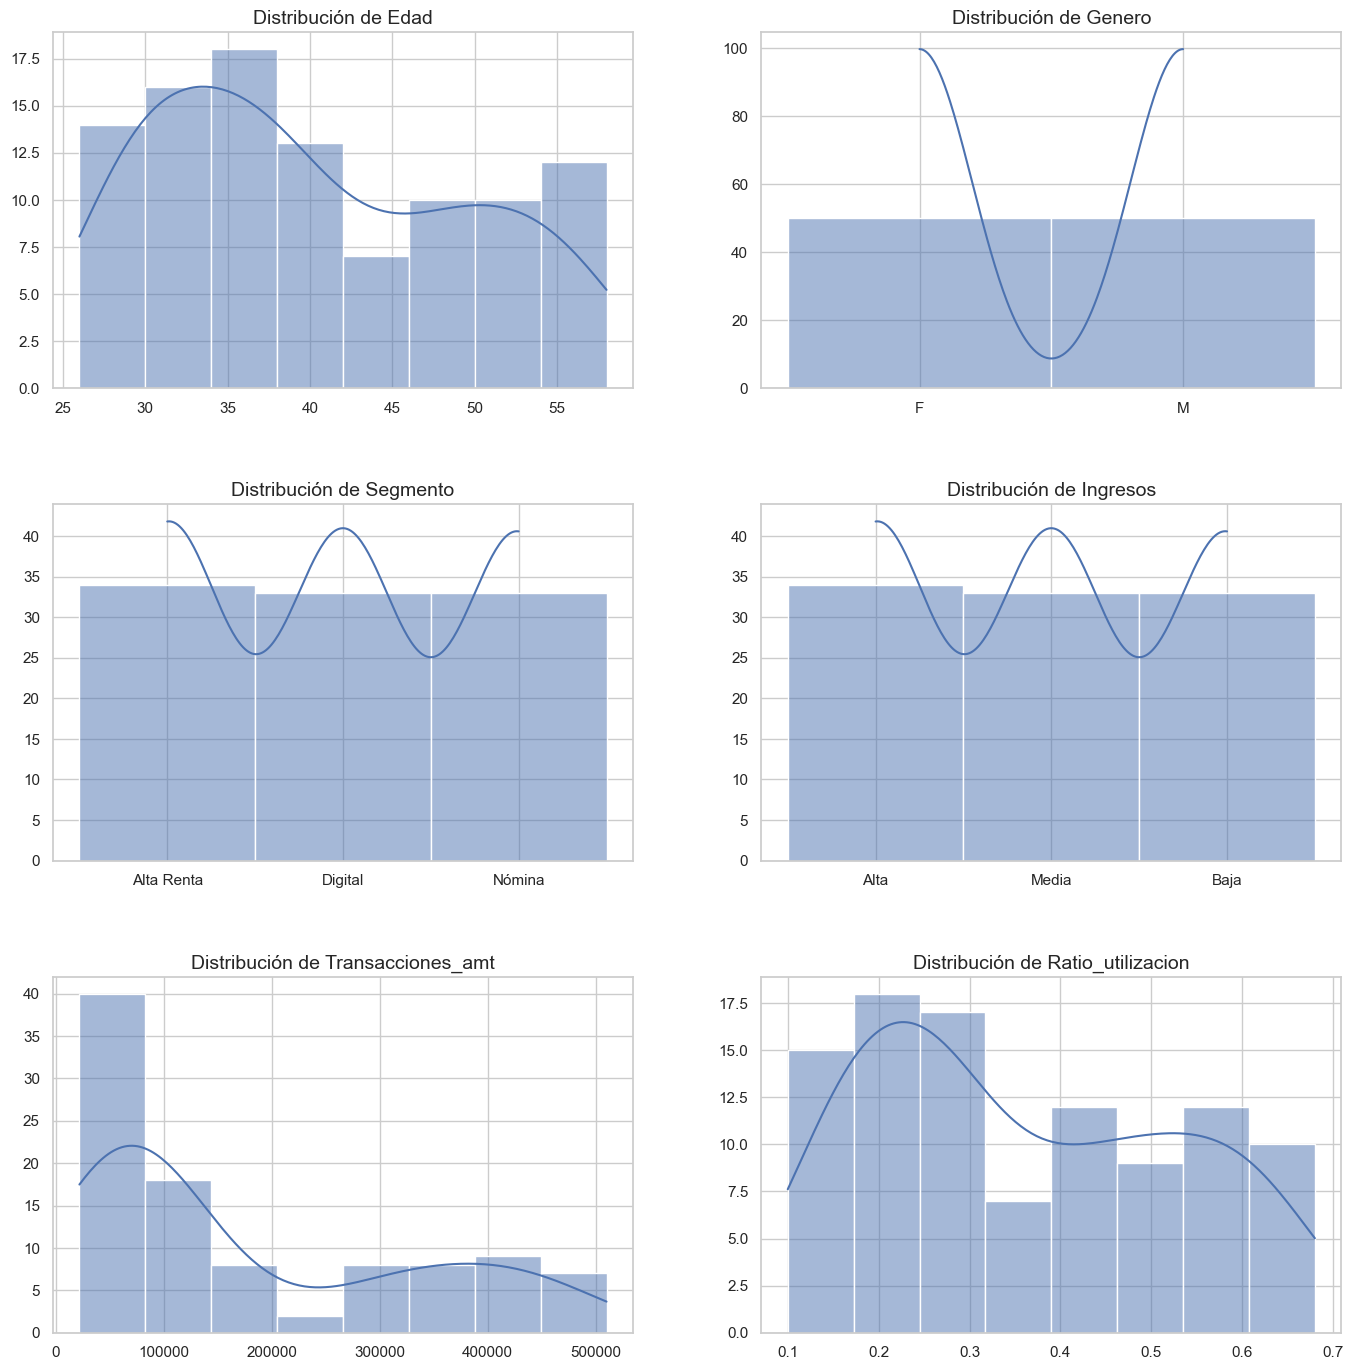

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilo
sns.set(style="whitegrid")

# Variables del CSV
variables_to_analyze = [
    'Edad',
    'Genero',
    'Segmento',
    'Ingresos',
    'Transacciones_amt',
    'Ratio_utilizacion'
]

# Crear figura
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 15))

# Ajustar espacios
plt.tight_layout(pad=5.0)

# Recorrer variables
for i, var in enumerate(variables_to_analyze):
    
    ax = axes[i // 2, i % 2]

    # Variables categóricas
    if sampled_data[var].dtype == 'object':
        sns.countplot(
            y=sampled_data[var],
            ax=ax
        )

    # Variables numéricas
    else:
        sns.histplot(
            sampled_data[var],
            kde=True,
            ax=ax
        )

    ax.set_title(f'Distribución de {var}', fontsize=14)
    ax.set_xlabel('')
    ax.set_ylabel('')

# Mostrar gráficos
plt.show()

# Analisis bivariado

/var/folders/xn/hk31cmbn33j2sp_0424kxs940000gn/T/ipykernel_33776/3406106745.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


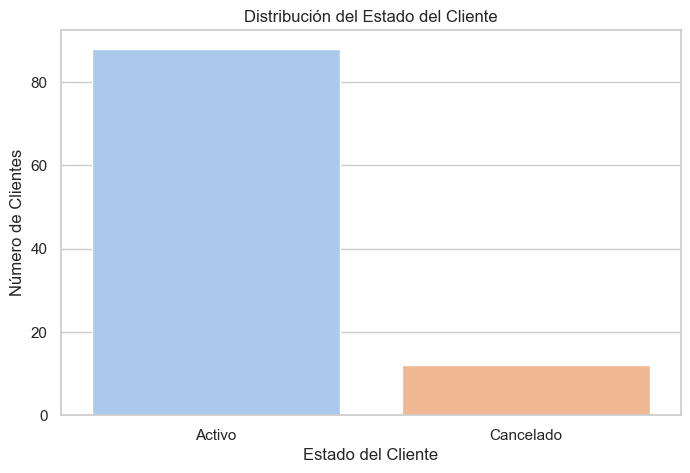

Estado_cliente
Activo       88
Cancelado    12
Name: count, dtype: int64


In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de gráficos
sns.set(style="whitegrid")

# Distribución de la variable Estado_cliente
estado_counts = sampled_data['Estado_cliente'].value_counts()

# Crear gráfico
plt.figure(figsize=(8, 5))

sns.barplot(
    x=estado_counts.index,
    y=estado_counts.values,
    palette="pastel"
)

# Títulos y etiquetas
plt.title('Distribución del Estado del Cliente')
plt.xlabel('Estado del Cliente')
plt.ylabel('Número de Clientes')

plt.xticks(rotation=0)

# Mostrar gráfico
plt.show()

# Mostrar conteos
print(estado_counts)

La distribución de la variable Attrition_Flag muestra que de los 10,127 clientes en el conjunto de datos, 8,500 son clientes existentes ("Existing Customer") y 1,627 son clientes que se han ido ("Attrited Customer"). Esto indica que aproximadamente el 16% de los clientes en este conjunto de datos han abandonado el banco.

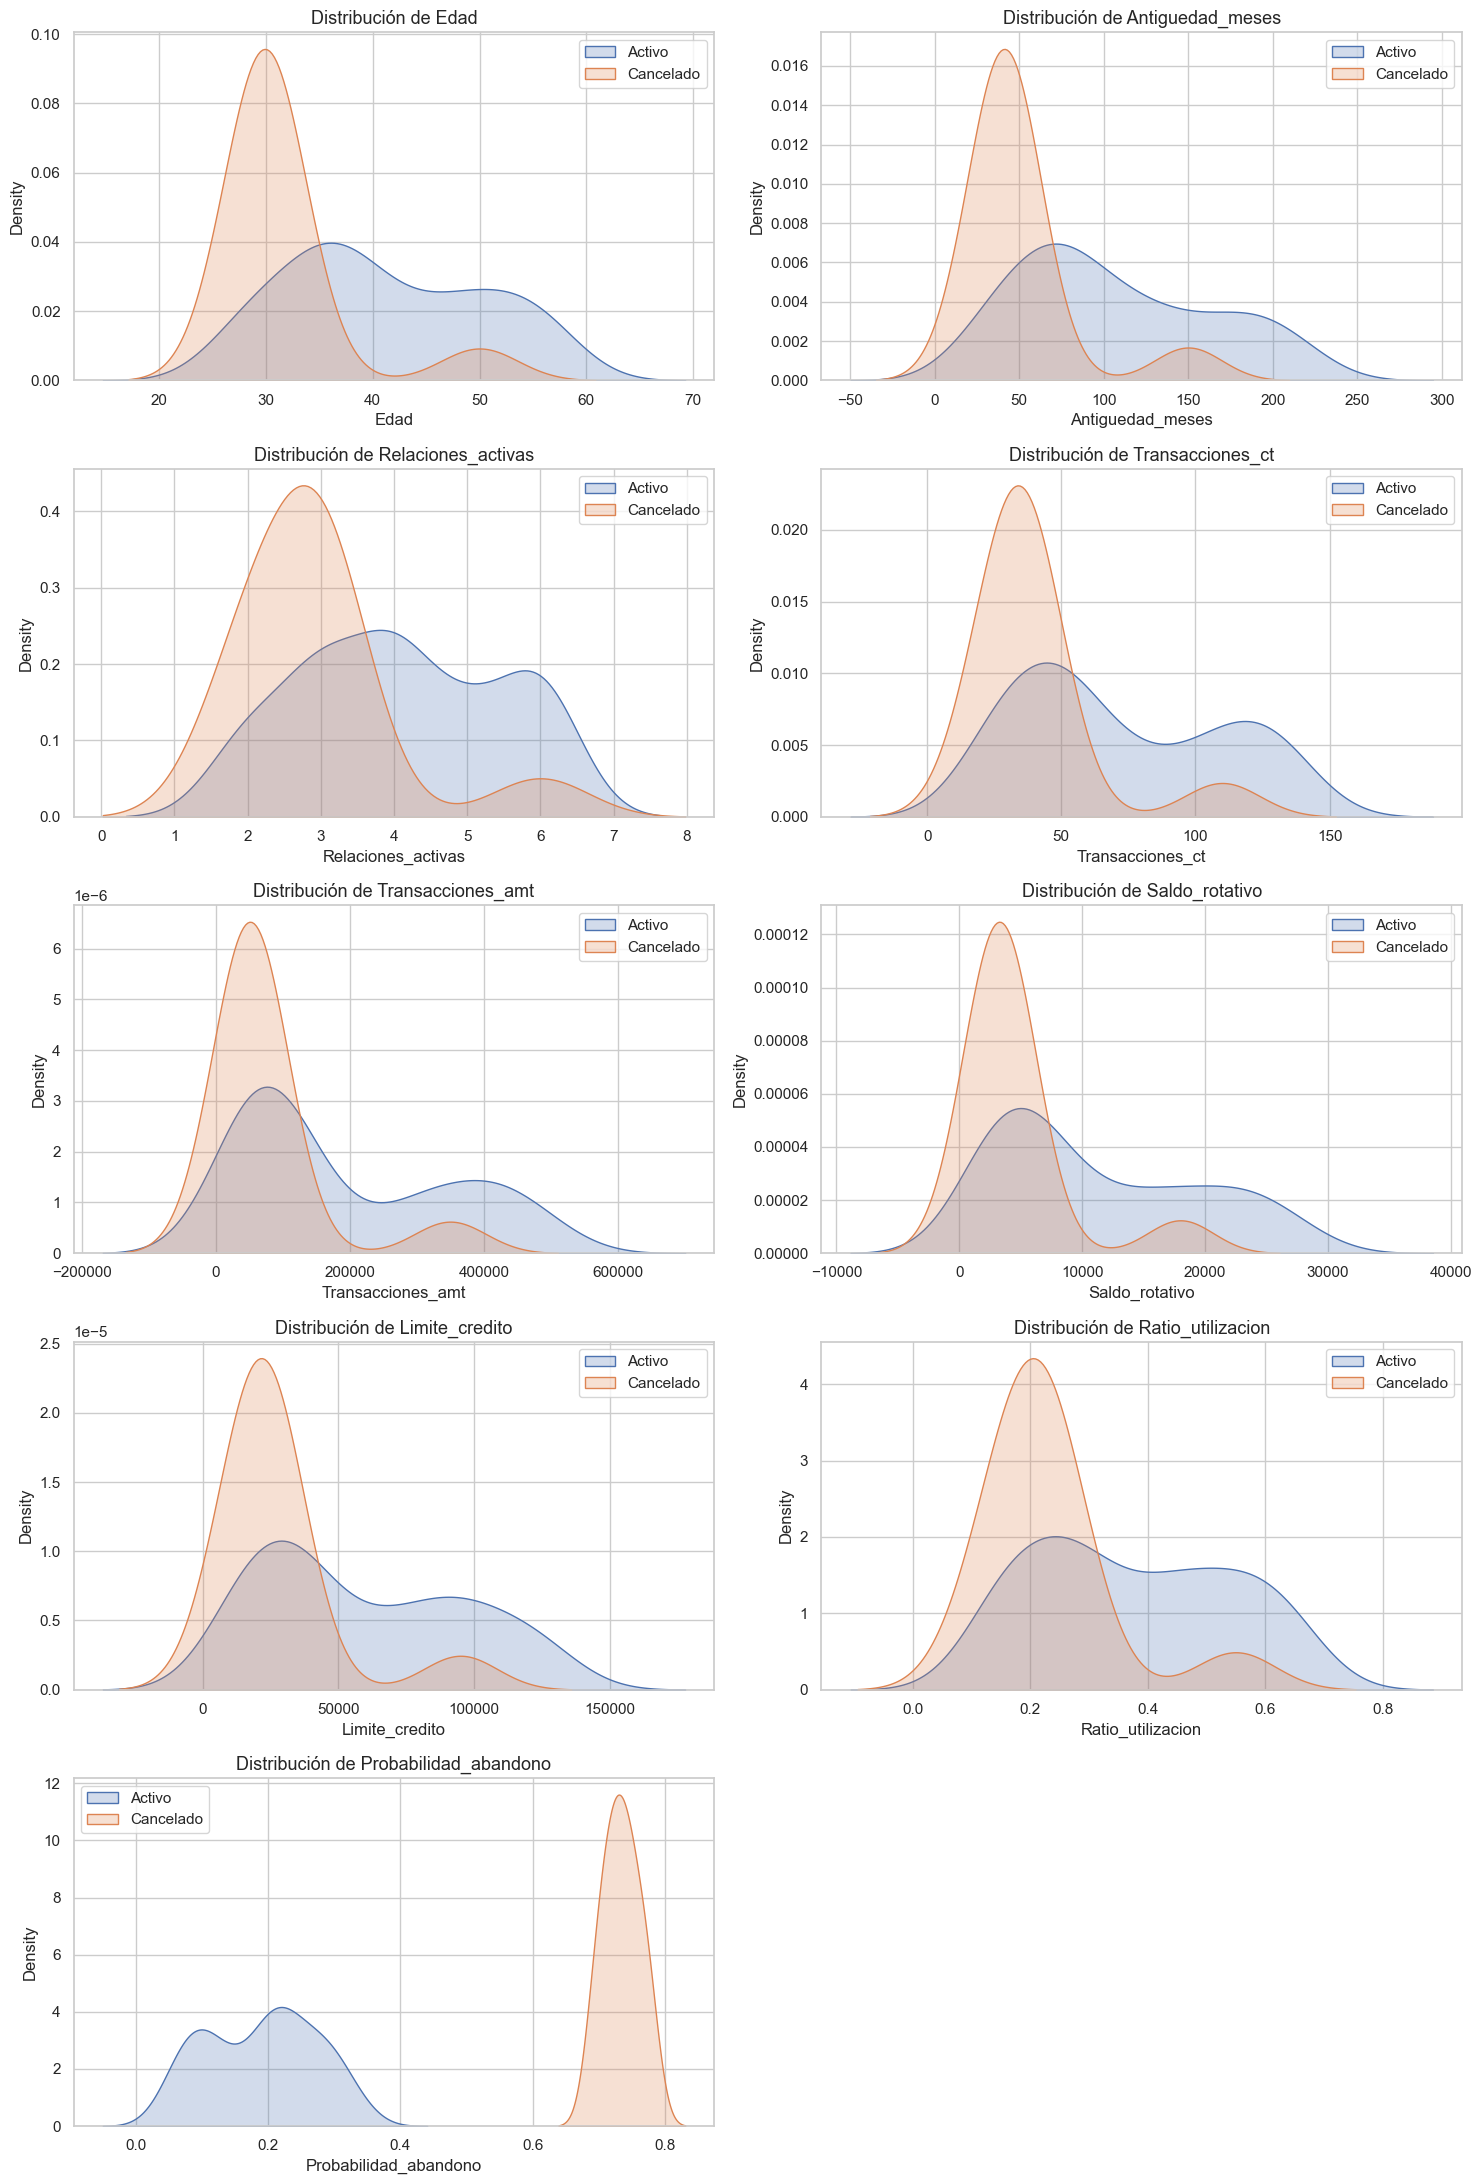

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

# Separar clientes activos y cancelados
clientes_activos = sampled_data[
    sampled_data['Estado_cliente'] == 'Activo'
]

clientes_cancelados = sampled_data[
    sampled_data['Estado_cliente'] == 'Cancelado'
]

# Variables numéricas del CSV
numeric_variables = [
    'Edad',
    'Antiguedad_meses',
    'Relaciones_activas',
    'Transacciones_ct',
    'Transacciones_amt',
    'Saldo_rotativo',
    'Limite_credito',
    'Ratio_utilizacion',
    'Probabilidad_abandono'
]

# Configuración de estilo
sns.set(style="whitegrid")

# Crear figura
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(15, 22))

# Convertir ejes en lista
axes = axes.flatten()

# Crear gráficos KDE
for i, var in enumerate(numeric_variables):

    sns.kdeplot(
        clientes_activos[var],
        label='Activo',
        fill=True,
        ax=axes[i]
    )

    sns.kdeplot(
        clientes_cancelados[var],
        label='Cancelado',
        fill=True,
        ax=axes[i]
    )

    axes[i].set_title(f'Distribución de {var}', fontsize=13)
    axes[i].legend()

# Eliminar gráfico vacío sobrante
fig.delaxes(axes[-1])

# Ajustar espacios
plt.tight_layout()

# Mostrar gráficos
plt.show()

/var/folders/xn/hk31cmbn33j2sp_0424kxs940000gn/T/ipykernel_33776/3196310129.py:35: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(


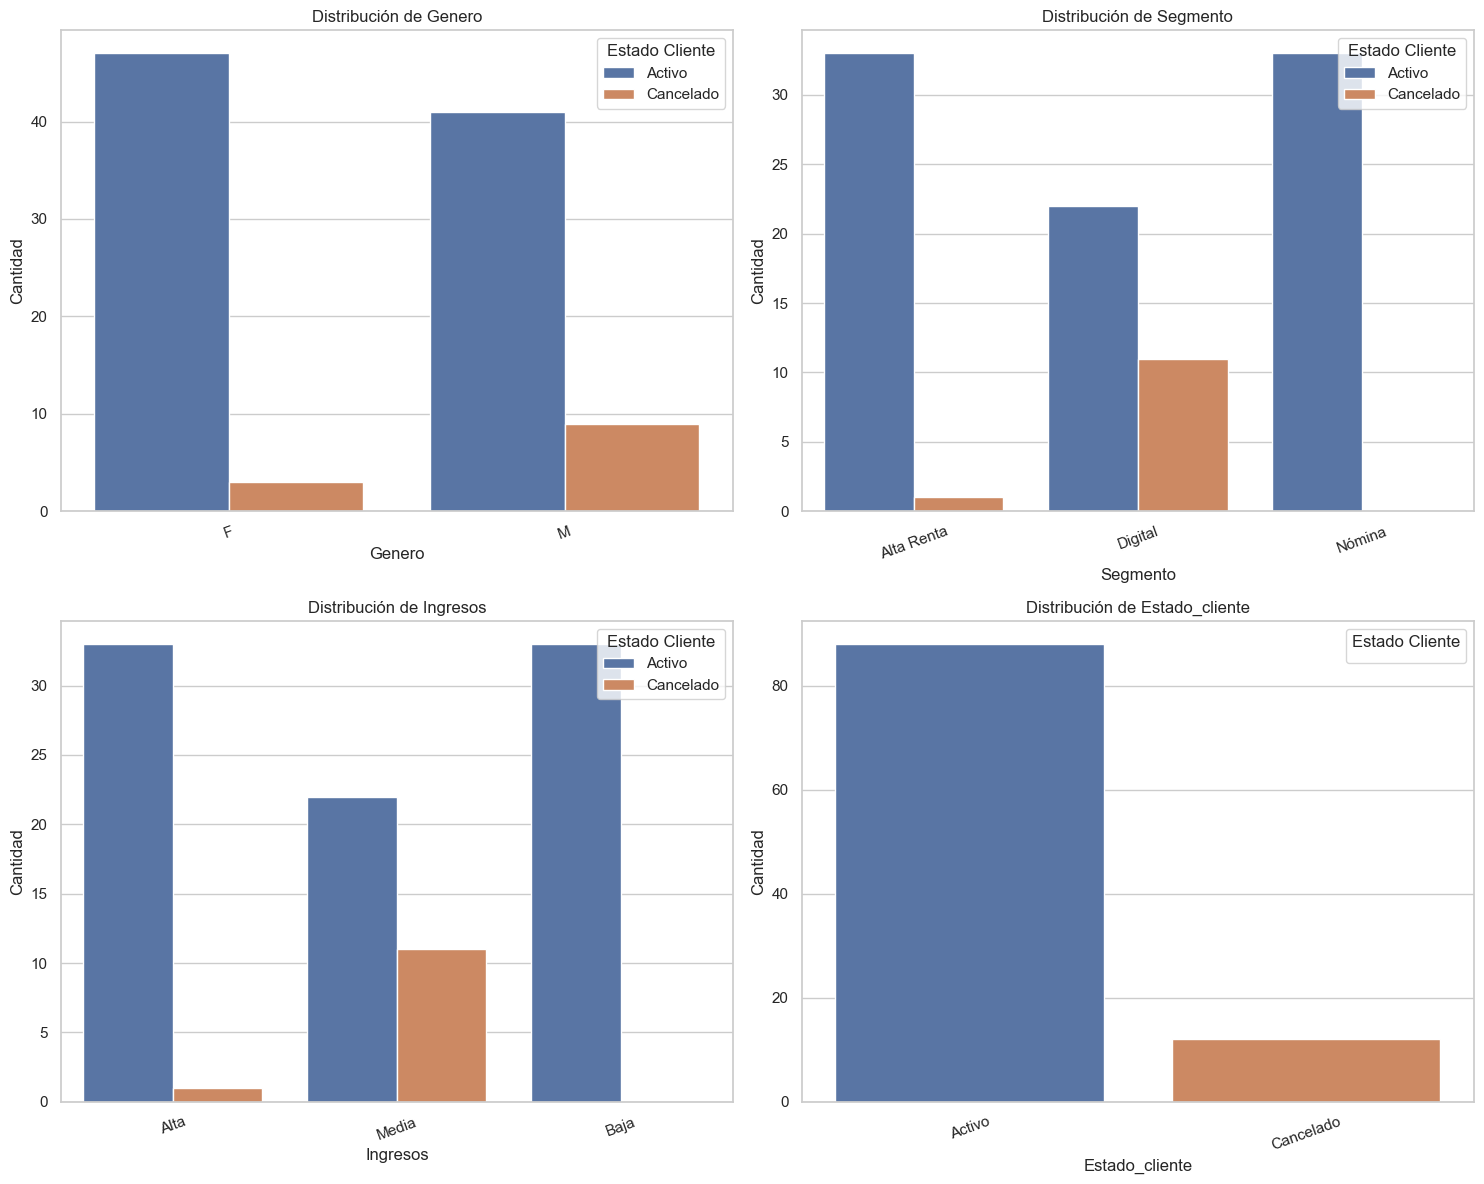

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de gráficos
sns.set(style="whitegrid")

# Tamaño de figura
plt.figure(figsize=(15, 12))

# Variables categóricas del CSV
categorical_vars = [
    'Genero',
    'Segmento',
    'Ingresos',
    'Estado_cliente'
]

# Crear gráficos
for i, var in enumerate(categorical_vars, 1):

    plt.subplot(2, 2, i)

    sns.countplot(
        data=sampled_data,
        x=var,
        hue='Estado_cliente'
    )

    plt.title(f'Distribución de {var}')
    plt.xlabel(var)
    plt.ylabel('Cantidad')

    plt.xticks(rotation=20)

    plt.legend(
        title='Estado Cliente',
        loc='upper right'
    )

# Ajustar espacios
plt.tight_layout()

# Mostrar gráficos
plt.show()

# Matriz de correlaciones

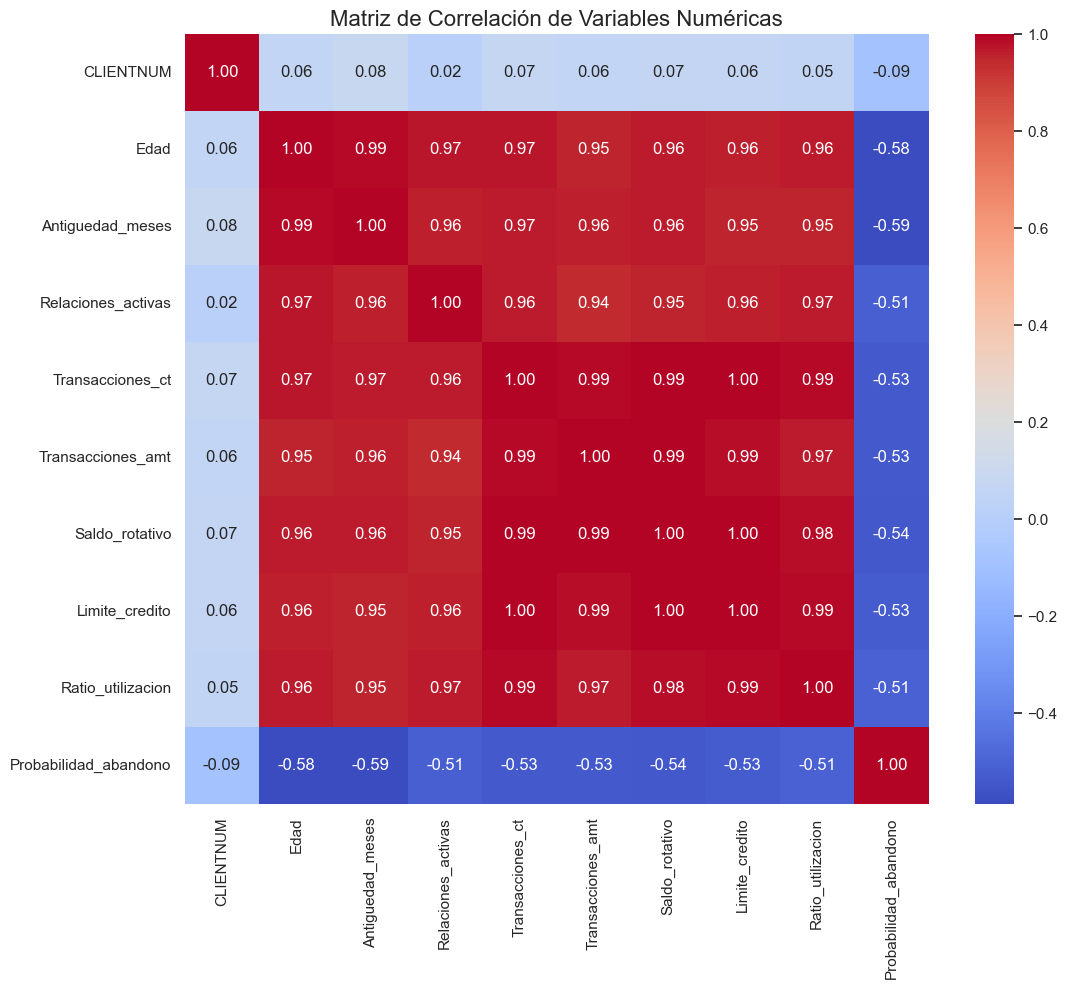

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

# Seleccionar únicamente variables numéricas
numeric_data = sampled_data.select_dtypes(
    include=['int64', 'float64']
)

# Calcular matriz de correlación
correlation_matrix = numeric_data.corr()

# Configuración del gráfico
plt.figure(figsize=(12, 10))

# Heatmap
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap='coolwarm'
)

# Título
plt.title(
    "Matriz de Correlación de Variables Numéricas",
    fontsize=16
)

# Mostrar gráfico
plt.show()

/var/folders/xn/hk31cmbn33j2sp_0424kxs940000gn/T/ipykernel_33776/3923544501.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  sampled_data.select_dtypes(include=['object']),


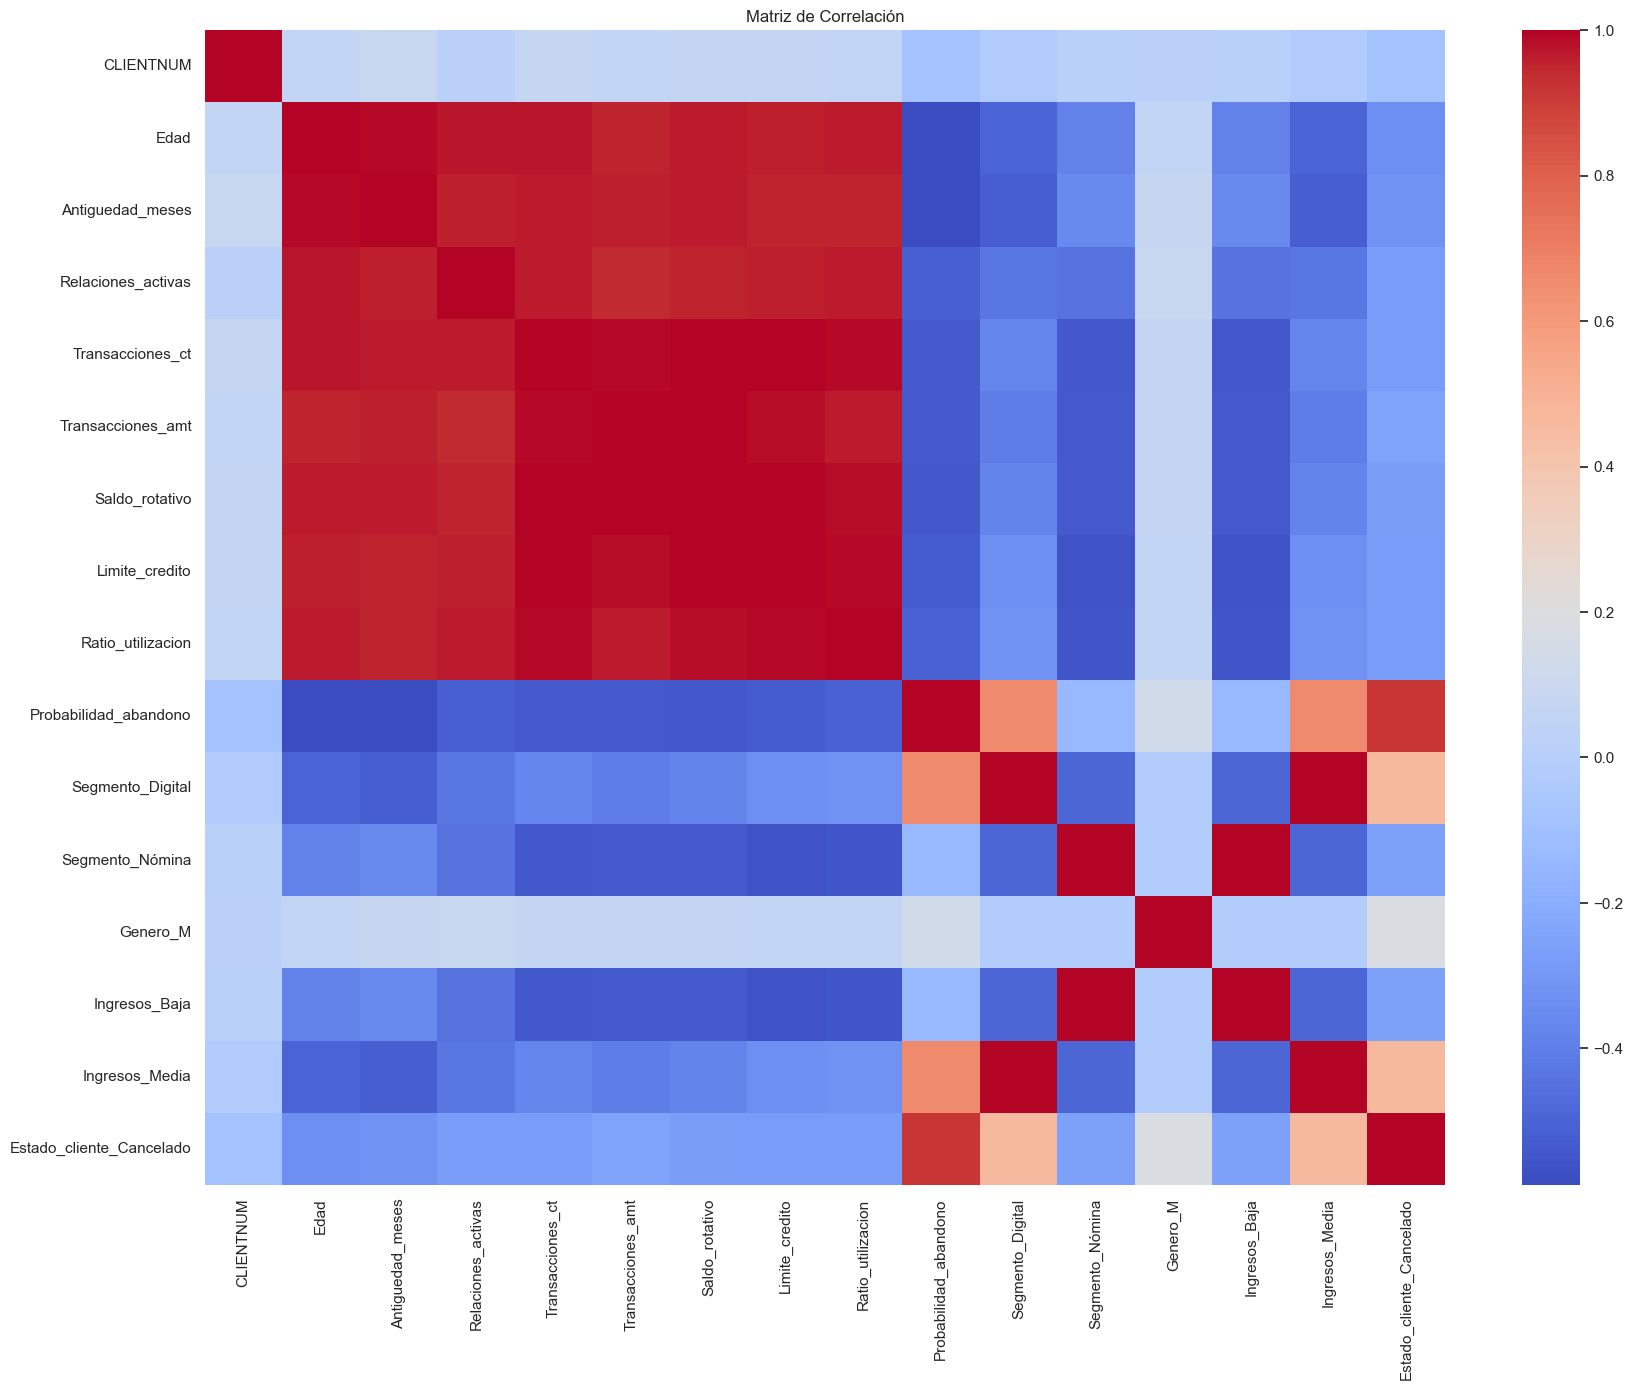

In [54]:
categorical_data = pd.get_dummies(
    sampled_data.select_dtypes(include=['object']),
    drop_first=True
)

combined_data = pd.concat([numeric_data, categorical_data], axis=1)

combined_correlation_matrix = combined_data.corr()

plt.figure(figsize=(20,15))

sns.heatmap(
    combined_correlation_matrix,
    annot=False,
    cmap='coolwarm'
)

plt.title("Matriz de Correlación")
plt.show()

# Analisis predictivo

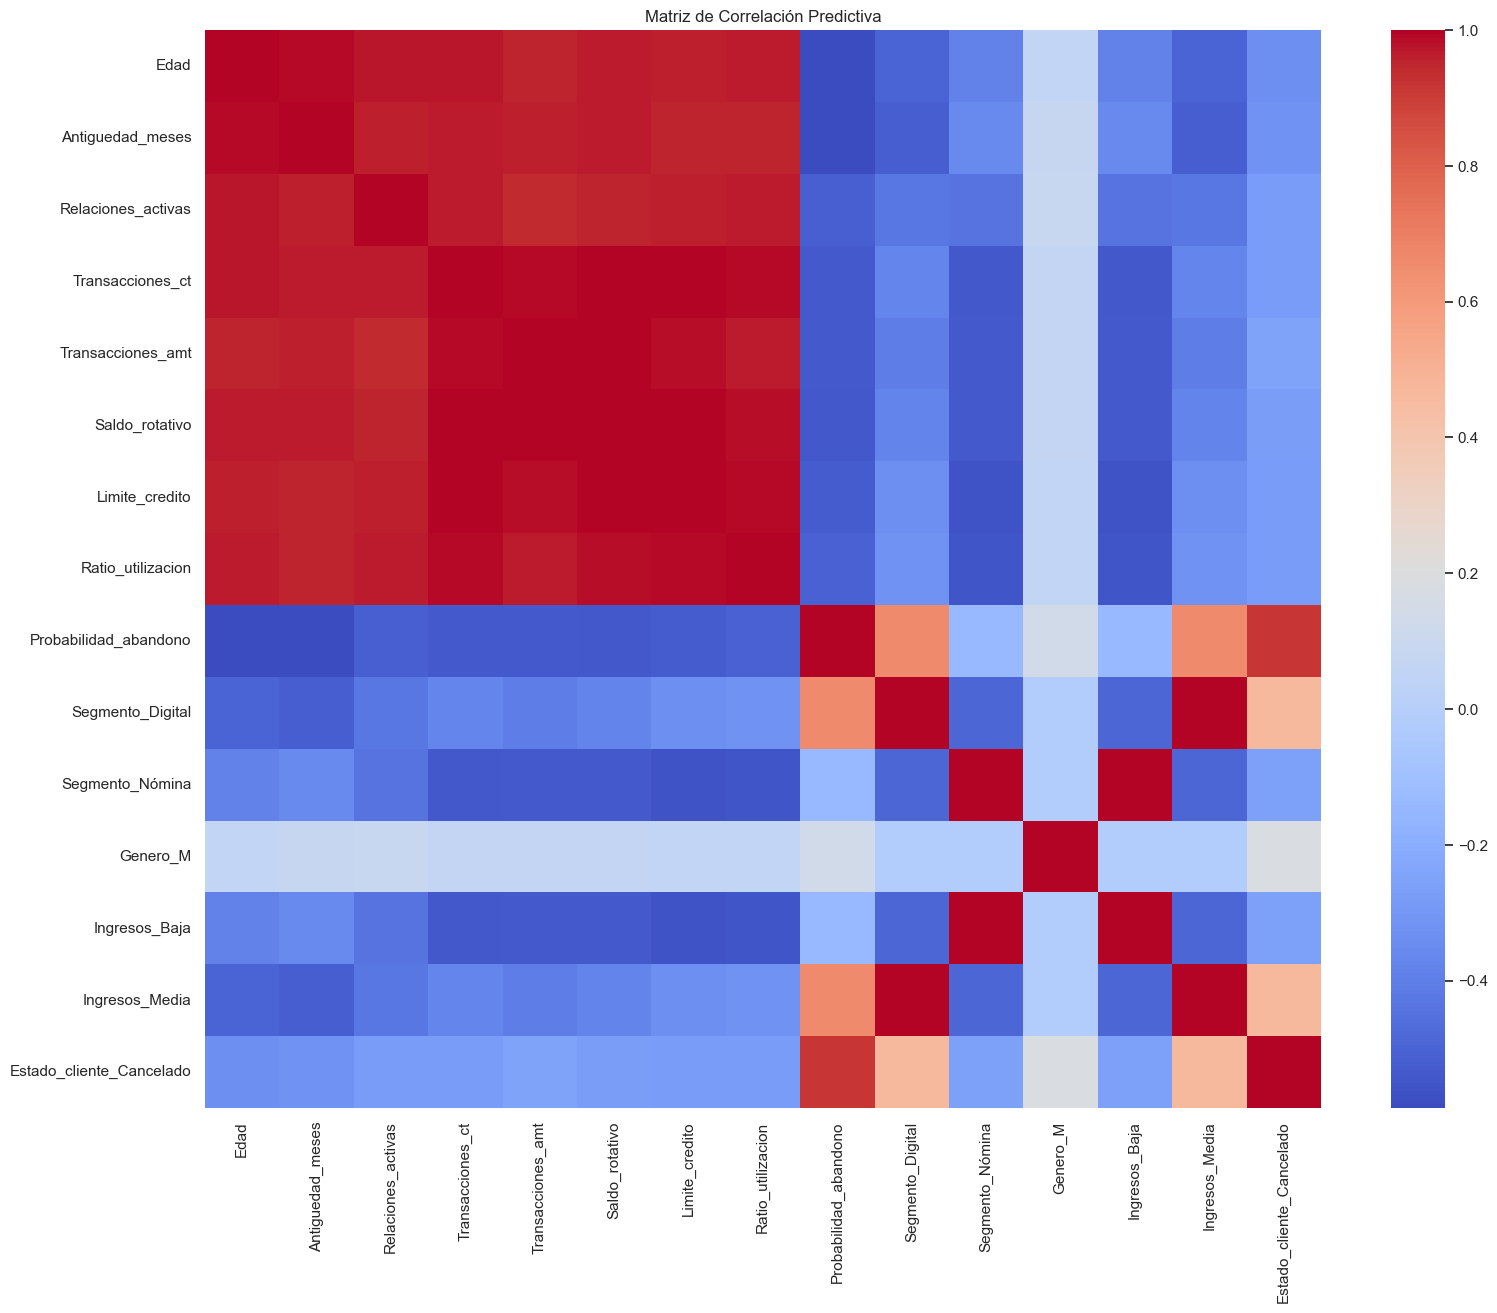

(100, 15)

In [55]:
# Eliminar variables no necesarias
predictive_data = combined_data.drop(
    columns=['CLIENTNUM']
)

# Matriz de correlación
predictive_correlation_matrix = predictive_data.corr()

plt.figure(figsize=(18, 14))

sns.heatmap(
    predictive_correlation_matrix,
    annot=False,
    cmap='coolwarm'
)

plt.title("Matriz de Correlación Predictiva")
plt.show()

# Dimensiones del dataset
predictive_data.shape

In [60]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

# 1. Cargar dataset
predictive_data = pd.read_csv("DaviData.csv")

# 2. Definir target (Estado_cliente → 1=Cancelado, 0=Activo)
y = predictive_data["Estado_cliente"].apply(lambda x: 1 if x == "Cancelado" else 0)

# 3. Features: eliminamos columnas no predictoras
X = predictive_data.drop(columns=["Estado_cliente", "Probabilidad_abandono"])

# 4. One-Hot Encoding para variables categóricas
X_encoded = pd.get_dummies(X, drop_first=True)

# 5. Dividir datos en train/test
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.3, random_state=42)

# 6. Inicializar modelos
logistic_regression_model = LogisticRegression(max_iter=1000, random_state=42)
decision_tree_model = DecisionTreeClassifier(random_state=42)
random_forest_model = RandomForestClassifier(random_state=42)

# 7. Entrenar modelos
logistic_regression_model.fit(X_train, y_train)
decision_tree_model.fit(X_train, y_train)
random_forest_model.fit(X_train, y_train)

# 8. Predicciones
logistic_regression_predictions = logistic_regression_model.predict(X_test)
decision_tree_predictions = decision_tree_model.predict(X_test)
random_forest_predictions = random_forest_model.predict(X_test)

# 9. Accuracy
logistic_regression_accuracy = accuracy_score(y_test, logistic_regression_predictions)
decision_tree_accuracy = accuracy_score(y_test, decision_tree_predictions)
random_forest_accuracy = accuracy_score(y_test, random_forest_predictions)

# 10. ROC AUC usando probabilidades
logistic_regression_auc = roc_auc_score(y_test, logistic_regression_model.predict_proba(X_test)[:, 1])
decision_tree_auc = roc_auc_score(y_test, decision_tree_model.predict_proba(X_test)[:, 1])
random_forest_auc = roc_auc_score(y_test, random_forest_model.predict_proba(X_test)[:, 1])

# 11. Reportes
print("Logistic Regression Report:\n", classification_report(y_test, logistic_regression_predictions))
print("Decision Tree Report:\n", classification_report(y_test, decision_tree_predictions))
print("Random Forest Report:\n", classification_report(y_test, random_forest_predictions))

(logistic_regression_accuracy, decision_tree_accuracy, random_forest_accuracy,
 logistic_regression_auc, decision_tree_auc, random_forest_auc)


Logistic Regression Report:
               precision    recall  f1-score   support

           0       0.88      0.96      0.92        24
           1       0.75      0.50      0.60         6

    accuracy                           0.87        30
   macro avg       0.82      0.73      0.76        30
weighted avg       0.86      0.87      0.86        30

Decision Tree Report:
               precision    recall  f1-score   support

           0       0.92      0.92      0.92        24
           1       0.67      0.67      0.67         6

    accuracy                           0.87        30
   macro avg       0.79      0.79      0.79        30
weighted avg       0.87      0.87      0.87        30

Random Forest Report:
               precision    recall  f1-score   support

           0       0.92      0.92      0.92        24
           1       0.67      0.67      0.67         6

    accuracy                           0.87        30
   macro avg       0.79      0.79      0.79        30

(0.8666666666666667,
 0.8666666666666667,
 0.8666666666666667,
 0.9166666666666666,
 0.7916666666666666,
 0.8541666666666669)

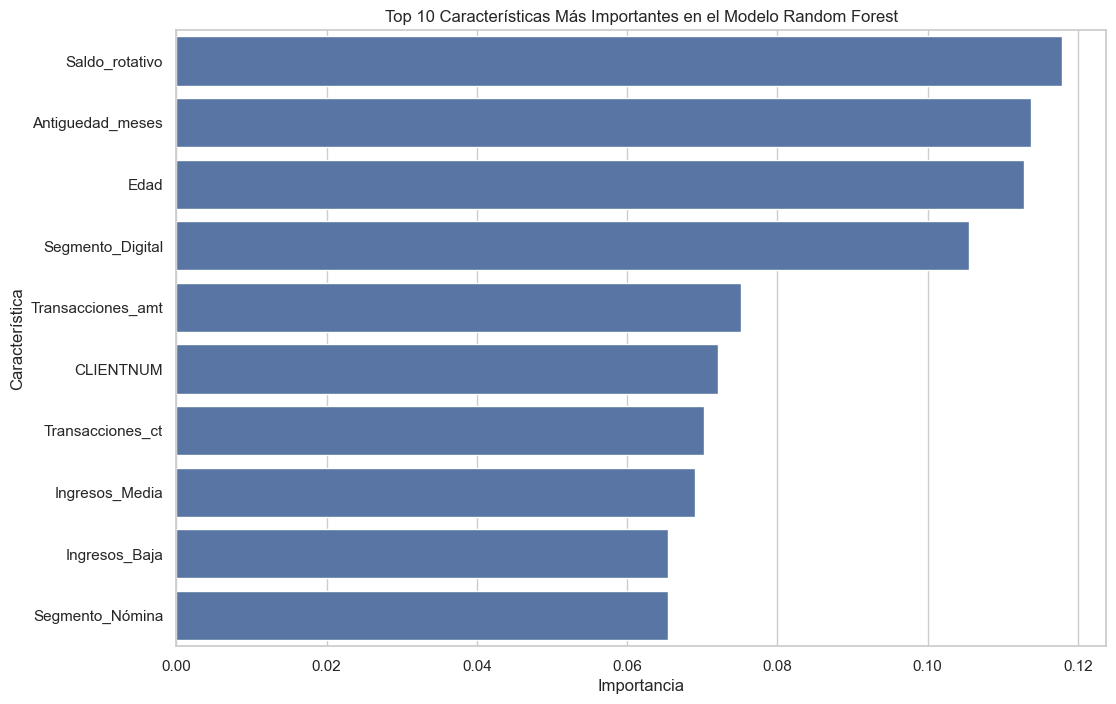

,Feature,Importance
6,Saldo_rotativo,0.117894
2,Antiguedad_meses,0.113734
1,Edad,0.112833
9,Segmento_Digital,0.105493
5,Transacciones_amt,0.075098
0,CLIENTNUM,0.072085
4,Transacciones_ct,0.070218
13,Ingresos_Media,0.069058
12,Ingresos_Baja,0.065490
10,Segmento_Nómina,0.065436


In [62]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Importancia de características del modelo Random Forest
feature_importances = random_forest_model.feature_importances_

# Crear DataFrame con las columnas codificadas
features_df = pd.DataFrame({
    'Feature': X_encoded.columns,
    'Importance': feature_importances
})

# Ordenar por importancia
features_df = features_df.sort_values(by='Importance', ascending=False)

# Visualizar las 10 más importantes
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=features_df.head(10))
plt.title('Top 10 Características Más Importantes en el Modelo Random Forest')
plt.xlabel('Importancia')
plt.ylabel('Característica')
plt.show()

# Mostrar tabla con las 10 más importantes
features_df.head(10)


In [63]:
from sklearn.model_selection import train_test_split

# Convertir objetivo a numérico
sampled_data['Estado_cliente'] = sampled_data['Estado_cliente'].map({
    'Activo': 0,
    'Cancelado': 1
})

# One-hot encoding
predictive_data = pd.get_dummies(sampled_data, drop_first=True)

# Variables predictoras y objetivo
X = predictive_data.drop(columns=['Estado_cliente'])
y = predictive_data['Estado_cliente']

# División de datos
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)

/var/folders/xn/hk31cmbn33j2sp_0424kxs940000gn/T/ipykernel_33776/2812191444.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


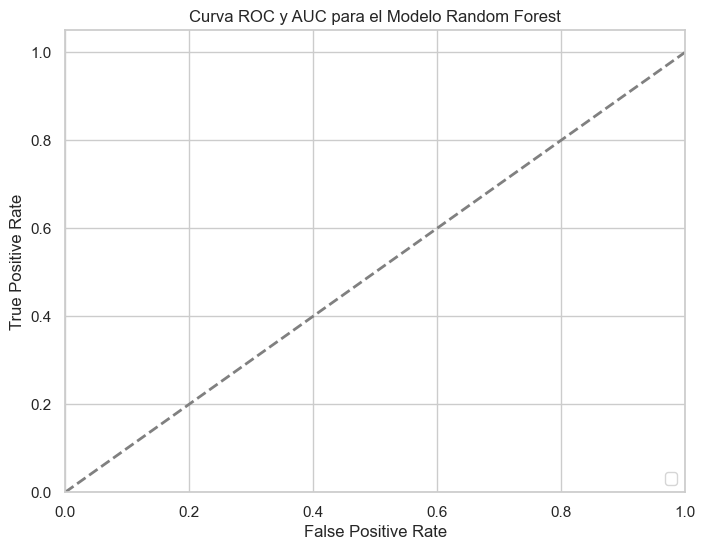

In [ ]:
# Creando la gráfica para la Curva ROC y AUC
plt.figure(figsize=(8, 6))
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC y AUC para el Modelo Random Forest')
plt.legend(loc="lower right")
plt.show()

In [64]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# 1. Cargar dataset
df = pd.read_csv("DaviData.csv")

# 2. Definir target (Estado_cliente → 0=Activo, 1=Cancelado)
y = df["Estado_cliente"].apply(lambda x: 1 if x == "Cancelado" else 0)

# 3. Eliminar columnas no predictoras
X = df.drop(columns=["Estado_cliente", "Probabilidad_abandono"])

# 4. Codificar variables categóricas con One-Hot Encoding
X_encoded = pd.get_dummies(X, drop_first=True)

# 5. Separar train/test
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

# 6. Entrenar modelo
random_forest_model = RandomForestClassifier(n_estimators=100, random_state=42)
random_forest_model.fit(X_train, y_train)




,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

En el contexto de las predicciones realizadas por el modelo de Random Forest, un valor de 1 en la columna Predicted_Churn significa que el modelo predice que el cliente está en riesgo de churn, es decir, es probable que deje de ser cliente del banco en un futuro cercano.